## ShopSmart Analytics: E-Commerce Data Intelligence System

---

> **Course:** Data Mining and Knowledge Discovery (INFO911)  
> **Dataset:** E-Commerce User Behavior (16,000 records)  
> **Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn

---



---
# Section 1: Setup & Imports


In [36]:
import warnings
warnings.filterwarnings('ignore')

In [74]:
# ============================================================
#  CORE LIBRARIES
# ============================================================
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import warnings
warnings.filterwarnings('ignore')

# ============================================================
#  VISUALIZATION LIBRARIES
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
#  MACHINE LEARNING — PREPROCESSING
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer

# ============================================================
#  MACHINE LEARNING — CLUSTERING
# ============================================================
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ============================================================
#  MACHINE LEARNING — CLASSIFICATION
# ============================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

# ============================================================
#  MACHINE LEARNING — REGRESSION
# ============================================================
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
#  GLOBAL SETTINGS
# ============================================================
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


In [38]:
warnings.filterwarnings('ignore')

---
# Section 2: Data Understanding & Preprocessing


In [39]:
# ============================================================
#  STEP 1: LOAD THE DATASET
# ============================================================

df = pd.read_csv('/content/final_ecommerce_dataset_16000.csv')

print('Dataset loaded successfully!')
print(f'   • Rows (users):    {df.shape[0]:,}')
print(f'   • Columns (features): {df.shape[1]}')

Dataset loaded successfully!
   • Rows (users):    16,000
   • Columns (features): 14


In [40]:
df.head(10)

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1,33.0,Female,Desktop,14.01,7,3,3,1,1,1,15.28,46.05,1
1,2,37.0,Male,Desktop,4.16,5,1,2,0,1,0,21.61,34.47,1
2,3,30.0,Female,Tablet,18.06,19,9,3,0,0,1,22.34,31.85,1
3,4,37.0,Male,Mobile,9.73,6,5,1,1,1,1,18.68,56.09,1
4,5,18.0,Female,Mobile,2.72,2,0,0,1,0,0,5.90,79.88,0
5,6,42.0,Male,Mobile,5.14,3,1,0,0,0,0,6.86,70.94,0
6,7,36.0,Female,Mobile,7.92,1,0,0,1,0,0,6.44,84.86,0
7,8,34.0,Male,Mobile,8.72,8,5,2,0,0,1,12.42,71.84,1
8,9,40.0,Male,Mobile,19.81,17,7,4,0,1,1,30.02,20.83,1
9,10,23.0,Male,Mobile,17.34,12,9,8,1,0,1,31.56,25.11,1


In [41]:
df.shape

(16000, 14)

In [42]:
# ============================================================
#  STEP 3: UNDERSTAND COLUMN MEANINGS
# ============================================================

print('Column Information:')
print('='*60)
df.info()

print('\nColumn Descriptions:')
column_descriptions = {
    'user_id'            : 'Unique identifier for each user',
    'age'                : 'Age of the user (18–59)',
    'gender'             : 'Gender of the user (Male/Female)',
    'device_type'        : 'Device used (Mobile/Desktop/Tablet)',
    'time_on_site'       : 'Total minutes spent on the website',
    'pages_viewed'       : 'Number of pages viewed per session',
    'previous_purchases' : 'Number of past purchases made',
    'cart_items'         : 'Number of items added to cart',
    'discount_seen'      : 'Whether user saw a discount (1=Yes, 0=No)',
    'ad_clicked'         : 'Whether user clicked an ad (1=Yes, 0=No)',
    'returning_user'     : 'Whether user has visited before (1=Yes, 0=No)',
    'avg_session_time'   : 'Average time per session (minutes)',
    'bounce_rate'        : 'Percentage of sessions where user left without interacting',
    'purchase'           : 'TARGET: Did user make a purchase? (1=Yes, 0=No)'
}
for col, desc in column_descriptions.items():
    print(f'   {col:<22} -> {desc}')

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             16000 non-null  int64  
 1   age                 15920 non-null  float64
 2   gender              16000 non-null  object 
 3   device_type         16000 non-null  object 
 4   time_on_site        15920 non-null  float64
 5   pages_viewed        16000 non-null  int64  
 6   previous_purchases  16000 non-null  int64  
 7   cart_items          16000 non-null  int64  
 8   discount_seen       16000 non-null  int64  
 9   ad_clicked          16000 non-null  int64  
 10  returning_user      16000 non-null  int64  
 11  avg_session_time    16000 non-null  float64
 12  bounce_rate         16000 non-null  float64
 13  purchase            16000 non-null  int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 1.7+ MB

Column Descriptions:
   

In [43]:
df.describe().round(2)

,user_id,age,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
count,16000.00,15920.00,15920.00,16000.00,16000.00,16000.00,16000.00,16000.00,16000.00,16000.00,16000.00,16000.00
mean,8000.50,37.61,12.68,7.88,3.99,2.63,0.54,0.45,0.60,15.19,52.29,0.79
std,4618.95,9.66,7.11,4.81,3.43,2.32,0.50,0.50,0.49,9.36,24.96,0.41
min,1.00,18.00,2.00,1.00,0.00,0.00,0.00,0.00,0.00,2.00,5.00,0.00
25%,4000.75,31.00,6.75,4.00,1.00,0.00,0.00,0.00,0.00,7.49,33.00,1.00
50%,8000.50,38.00,11.90,7.00,3.00,2.00,1.00,0.00,1.00,14.08,50.45,1.00
75%,12000.25,44.00,16.90,11.00,5.00,4.00,1.00,1.00,1.00,19.67,72.60,1.00
max,16000.00,60.00,29.99,19.00,13.00,8.00,1.00,1.00,1.00,40.00,100.00,1.00


Missing Values Report:
              Missing Count  Missing %
age                      80        0.5
time_on_site             80        0.5

   Total missing cells: 160
   Total cells in dataset: 224,000
   Overall missing rate: 0.07%


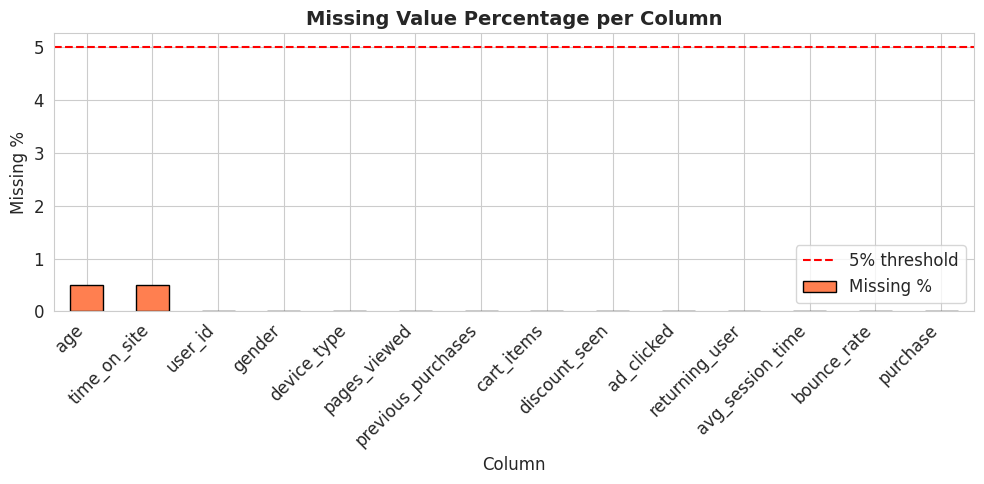

In [44]:
# ============================================================
#  STEP 5: CHECK FOR MISSING VALUES
#  We calculate: (missing count / total rows) * 100 = % missing
# ============================================================

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Missing Values Report:')
print('='*45)
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\n   Total missing cells: {missing.sum():,}')
print(f'   Total cells in dataset: {df.size:,}')
print(f'   Overall missing rate: {(missing.sum()/df.size*100):.2f}%')

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='bar', color='coral', edgecolor='black', ax=ax)
ax.set_title('Missing Value Percentage per Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.axhline(y=5, color='red', linestyle='--', label='5% threshold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# ============================================================
#  STEP 6: HANDLE MISSING VALUES
#
#  Strategy:
#  - Numeric columns  → Fill with MEDIAN (more robust than mean
#    because median is not affected by outliers)
#  - Categorical cols → Fill with MODE (most frequent category)
# ============================================================

df_clean = df.copy()

# Identify numeric and categorical columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

# Fill numeric missing values with median
for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'  -> {col:<25} -> filled with median = {median_val:.2f}')

# Fill categorical missing values with mode
for col in categorical_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f'  -> {col:<25} -> filled with mode = "{mode_val}"')

print(f'\nMissing values after cleaning: {df_clean.isnull().sum().sum()}')
print(f'   Dataset shape now: {df_clean.shape}')

Numeric columns: ['user_id', 'age', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'discount_seen', 'ad_clicked', 'returning_user', 'avg_session_time', 'bounce_rate', 'purchase']
Categorical columns: ['gender', 'device_type']
  -> user_id                   -> filled with median = 8000.50
  -> age                       -> filled with median = 38.00
  -> time_on_site              -> filled with median = 11.90
  -> pages_viewed              -> filled with median = 7.00
  -> previous_purchases        -> filled with median = 3.00
  -> cart_items                -> filled with median = 2.00
  -> discount_seen             -> filled with median = 1.00
  -> ad_clicked                -> filled with median = 0.00
  -> returning_user            -> filled with median = 1.00
  -> avg_session_time          -> filled with median = 14.08
  -> bounce_rate               -> filled with median = 50.45
  -> purchase                  -> filled with median = 1.00
  -> gender               

Outlier Detection using IQR Method:
   age                   :     0 outliers  (bounds: [11.50, 63.50])
   time_on_site          :     0 outliers  (bounds: [-8.38, 32.02])
   pages_viewed          :     0 outliers  (bounds: [-6.50, 21.50])
   bounce_rate           :     0 outliers  (bounds: [-26.40, 132.01])
   avg_session_time      :   314 outliers  (bounds: [-10.78, 37.94])
   previous_purchases    :   844 outliers  (bounds: [-5.00, 11.00])
   cart_items            :     0 outliers  (bounds: [-6.00, 10.00])


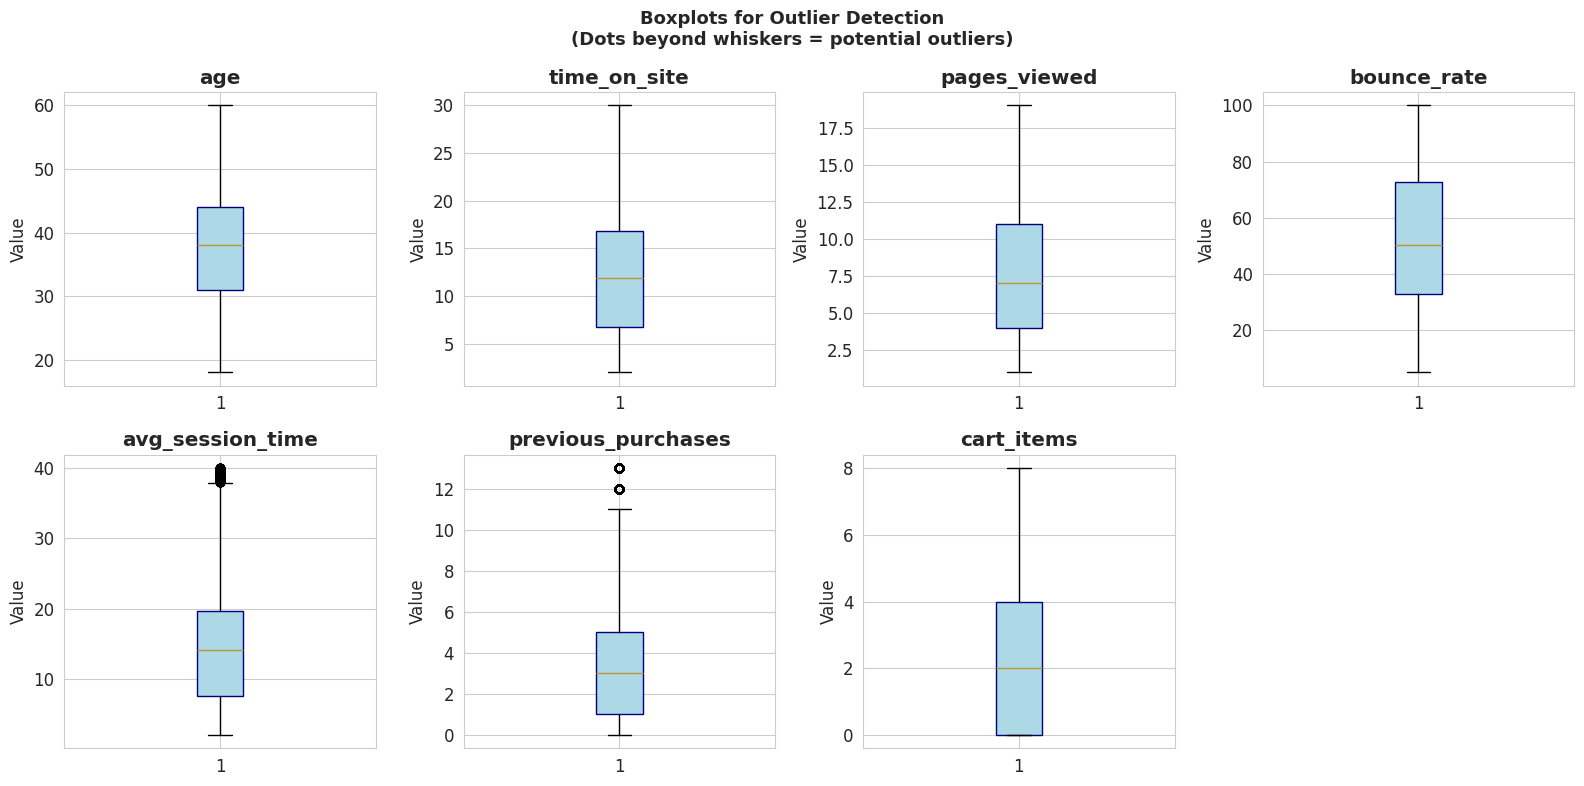

In [46]:
# ============================================================
#  STEP 7: DETECT OUTLIERS
#
#  We use the IQR (Interquartile Range) method:
#  - Q1 = 25th percentile (lower quarter)
#  - Q3 = 75th percentile (upper quarter)
#  - IQR = Q3 - Q1
#  - Outlier if value < Q1 - 1.5*IQR  OR  > Q3 + 1.5*IQR
# ============================================================

key_features = ['age', 'time_on_site', 'pages_viewed', 'bounce_rate',
                'avg_session_time', 'previous_purchases', 'cart_items']

print('Outlier Detection using IQR Method:')
print('='*60)

outlier_counts = {}
for col in key_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_counts[col] = outliers
    print(f'   {col:<22}: {outliers:>5} outliers  (bounds: [{lower:.2f}, {upper:.2f}])')

# Visualize with boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_features):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')
axes[-1].axis('off')  # Hide last empty subplot
plt.suptitle('Boxplots for Outlier Detection\n(Dots beyond whiskers = potential outliers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
#  STEP 8: FEATURE ENGINEERING
#
#  Feature engineering = creating NEW columns from existing ones
#  to give our models more useful information.
# ============================================================

# 1. Engagement Score (higher = more engaged user)
df_clean['engagement_score'] = (
    (df_clean['time_on_site'] / df_clean['time_on_site'].max()) * 0.3 +
    (df_clean['pages_viewed'] / df_clean['pages_viewed'].max()) * 0.3 +
    (df_clean['avg_session_time'] / df_clean['avg_session_time'].max()) * 0.2 +
    ((100 - df_clean['bounce_rate']) / 100) * 0.2
).round(4)

# 2. Age Group (categorical bins)
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[17, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-59']
)

# 3. High Value User flag (top 25% in previous purchases AND cart items)
pp_thresh = df_clean['previous_purchases'].quantile(0.75)
ci_thresh  = df_clean['cart_items'].quantile(0.75)
df_clean['high_value_user'] = (
    (df_clean['previous_purchases'] >= pp_thresh) &
    (df_clean['cart_items'] >= ci_thresh)
).astype(int)

# 4. Interaction Score (did they both click ad AND see discount?)
df_clean['interaction_score'] = df_clean['ad_clicked'] + df_clean['discount_seen']

print('New features created:')
new_features = ['engagement_score', 'age_group', 'high_value_user', 'interaction_score']
for f in new_features:
    print(f'   --{f}')
print(f'\n   Dataset now has {df_clean.shape[1]} columns (was 14)')
df_clean[['age', 'age_group', 'engagement_score', 'high_value_user', 'interaction_score']].head(6)

New features created:
   --engagement_score
   --age_group
   --high_value_user
   --interaction_score

   Dataset now has 18 columns (was 14)


,age,age_group,engagement_score,high_value_user,interaction_score
0,33.0,26-35,0.4350,0,2
1,37.0,36-45,0.3597,0,1
2,30.0,26-35,0.7287,0,0
3,37.0,36-45,0.3733,0,2
4,18.0,18-25,0.1285,0,1
5,42.0,36-45,0.1912,0,0


In [48]:
# ============================================================
#  STEP 9: ENCODING CATEGORICAL VARIABLES
#  1. Label Encoding: Female=0, Male=1 (for binary)
#  2. One-Hot Encoding: Creates separate column per category
#     e.g. device_type → device_Mobile, device_Desktop, device_Tablet
# ============================================================

df_encoded = df_clean.copy()

# Label encode binary column (gender)
le = LabelEncoder()
df_encoded['gender_encoded'] = le.fit_transform(df_encoded['gender'])
print('Label Encoding for gender:')
print('   ', dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot encode device_type (3 categories)
device_dummies = pd.get_dummies(df_encoded['device_type'], prefix='device')
df_encoded = pd.concat([df_encoded, device_dummies], axis=1)
print('\nOne-Hot Encoding for device_type:')
print('   New columns:', list(device_dummies.columns))

# Drop original categorical columns (replaced by encoded versions)
df_encoded = df_encoded.drop(['gender', 'device_type', 'age_group'], axis=1)

print(f'\nDataset shape after encoding: {df_encoded.shape}')
print('\nFirst few rows of encoded data:')
df_encoded.head(3)

Label Encoding for gender:
    {'Female': np.int64(0), 'Male': np.int64(1)}

One-Hot Encoding for device_type:
   New columns: ['device_Desktop', 'device_Mobile', 'device_Tablet']

Dataset shape after encoding: (16000, 19)

First few rows of encoded data:


,user_id,age,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase,engagement_score,high_value_user,interaction_score,gender_encoded,device_Desktop,device_Mobile,device_Tablet
0,1,33.0,14.01,7,3,3,1,1,1,15.28,46.05,1,0.4350,0,2,0,True,False,False
1,2,37.0,4.16,5,1,2,0,1,0,21.61,34.47,1,0.3597,0,1,1,True,False,False
2,3,30.0,18.06,19,9,3,0,0,1,22.34,31.85,1,0.7287,0,0,0,False,False,True


In [49]:
# ============================================================
#  STEP 10: FEATURE SCALING
# ============================================================

# Features to scale (only continuous numeric ones)
scale_cols = ['age', 'time_on_site', 'pages_viewed', 'previous_purchases',
              'cart_items', 'avg_session_time', 'bounce_rate', 'engagement_score']

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

print('Feature Scaling Applied (StandardScaler):')
print('='*50)
comparison = pd.DataFrame({
    'Before (Mean)' : df_encoded[scale_cols].mean().round(2),
    'After (Mean)'  : df_scaled[scale_cols].mean().round(4),
    'Before (Std)'  : df_encoded[scale_cols].std().round(2),
    'After (Std)'   : df_scaled[scale_cols].std().round(4)
})
print(comparison)
print('\nAll features now have Mean ≈ 0 and Std ≈ 1')
print('We use df_encoded for tree-based models (no scaling needed)')
print('and df_scaled for distance-based models (SVM, KMeans, Neural Net)')

Feature Scaling Applied (StandardScaler):
                    Before (Mean)  After (Mean)  Before (Std)  After (Std)
age                         37.61           0.0          9.63          1.0
time_on_site                12.67           0.0          7.09          1.0
pages_viewed                 7.88           0.0          4.81          1.0
previous_purchases           3.99           0.0          3.43          1.0
cart_items                   2.63           0.0          2.32          1.0
avg_session_time            15.19           0.0          9.36          1.0
bounce_rate                 52.29           0.0         24.96          1.0
engagement_score             0.42           0.0          0.22          1.0

All features now have Mean ≈ 0 and Std ≈ 1
We use df_encoded for tree-based models (no scaling needed)
and df_scaled for distance-based models (SVM, KMeans, Neural Net)


---
# Section 3: Exploratory Data Analysis (EDA)



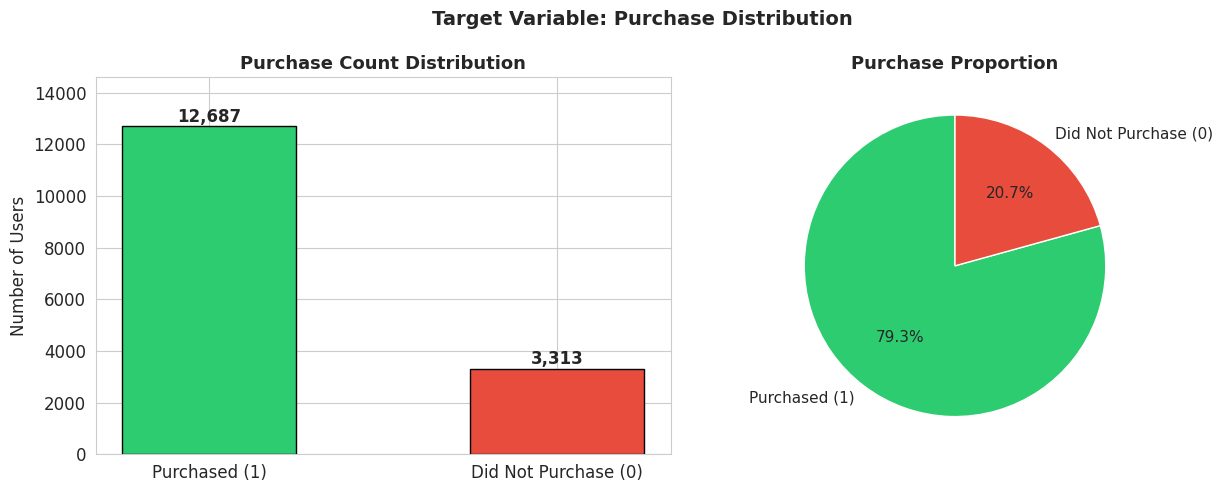


Purchased (1):     12,687 users (79.3%)
Did Not Buy (0):  3,313 users (20.7%)


In [78]:
# ============================================================
#  CHART 1: TARGET VARIABLE DISTRIBUTION
# ============================================================

purchase_counts = df_clean['purchase'].value_counts()
labels = ['Purchased (1)', 'Did Not Purchase (0)']
colors = ['#2ECC71', '#E74C3C']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar Chart
bars = ax1.bar(labels, purchase_counts.values, color=colors, edgecolor='black', width=0.5)
for bar, count in zip(bars, purchase_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax1.set_title('Purchase Count Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Users')
ax1.set_ylim(0, max(purchase_counts.values) * 1.15)

# Pie Chart
ax2.pie(purchase_counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax2.set_title('Purchase Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Purchase Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nPurchased (1):     {purchase_counts.get(1.0, 0):,} users ({purchase_counts.get(1.0, 0)/len(df_clean)*100:.1f}%)')
print(f'Did Not Buy (0):  {purchase_counts.get(0.0, 0):,} users ({purchase_counts.get(0.0, 0)/len(df_clean)*100:.1f}%)')

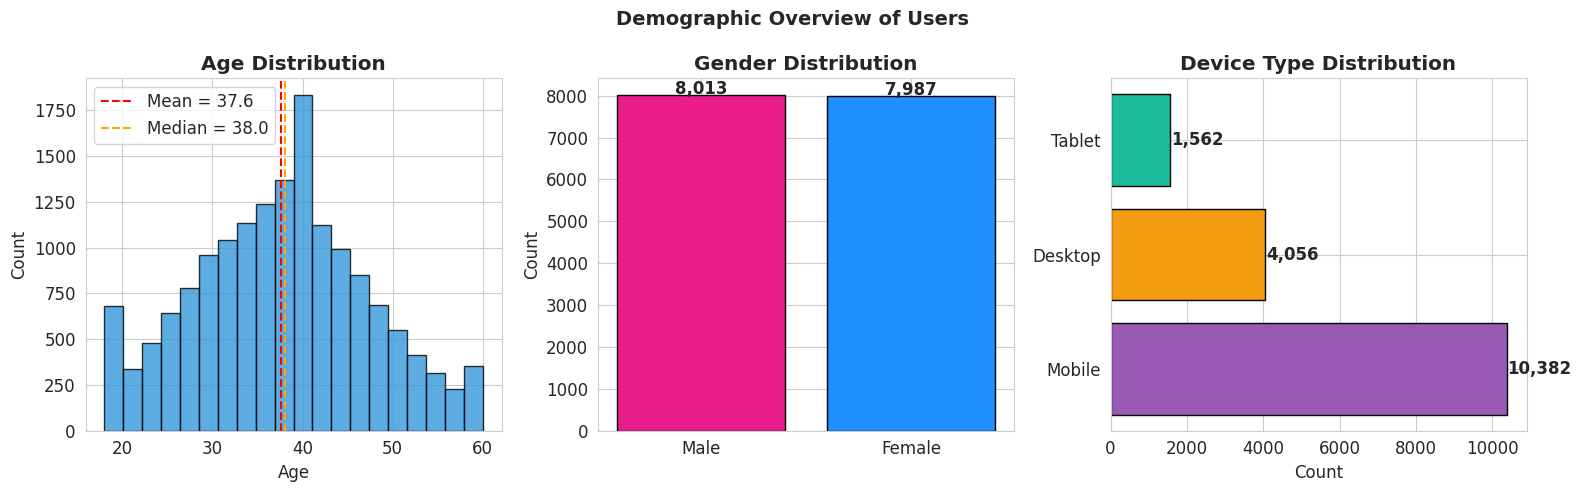


Key Insights:
->Gender split: 8,013 Males vs 7,987 Females
->Most popular device: Mobile (10,382 users)


In [80]:
# ============================================================
#  CHART 2: DEMOGRAPHIC ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age Distribution
axes[0].hist(df_clean['age'], bins=20, color='#3498DB', edgecolor='black', alpha=0.8)
axes[0].axvline(df_clean['age'].mean(), color='red', linestyle='--',
                label=f'Mean = {df_clean["age"].mean():.1f}')
axes[0].axvline(df_clean['age'].median(), color='orange', linestyle='--',
                label=f'Median = {df_clean["age"].median():.1f}')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Gender Distribution
gender_counts = df_clean['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values,
            color=['#E91E8C', '#1E90FF'], edgecolor='black')
for i, (cat, val) in enumerate(gender_counts.items()):
    axes[1].text(i, val + 20, f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('Gender Distribution', fontweight='bold')
axes[1].set_ylabel('Count')

# Device Type Distribution
device_counts = df_clean['device_type'].value_counts()
axes[2].barh(device_counts.index, device_counts.values,
             color=['#9B59B6', '#F39C12', '#1ABC9C'], edgecolor='black')
for i, val in enumerate(device_counts.values):
    axes[2].text(val + 20, i, f'{val:,}', va='center', fontweight='bold')
axes[2].set_title('Device Type Distribution', fontweight='bold')
axes[2].set_xlabel('Count')

plt.suptitle('Demographic Overview of Users', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey Insights:')
print(f'->Gender split: {gender_counts.iloc[0]:,} {gender_counts.index[0]}s vs {gender_counts.iloc[1]:,} {gender_counts.index[1]}s')
print(f'->Most popular device: {device_counts.index[0]} ({device_counts.iloc[0]:,} users)')

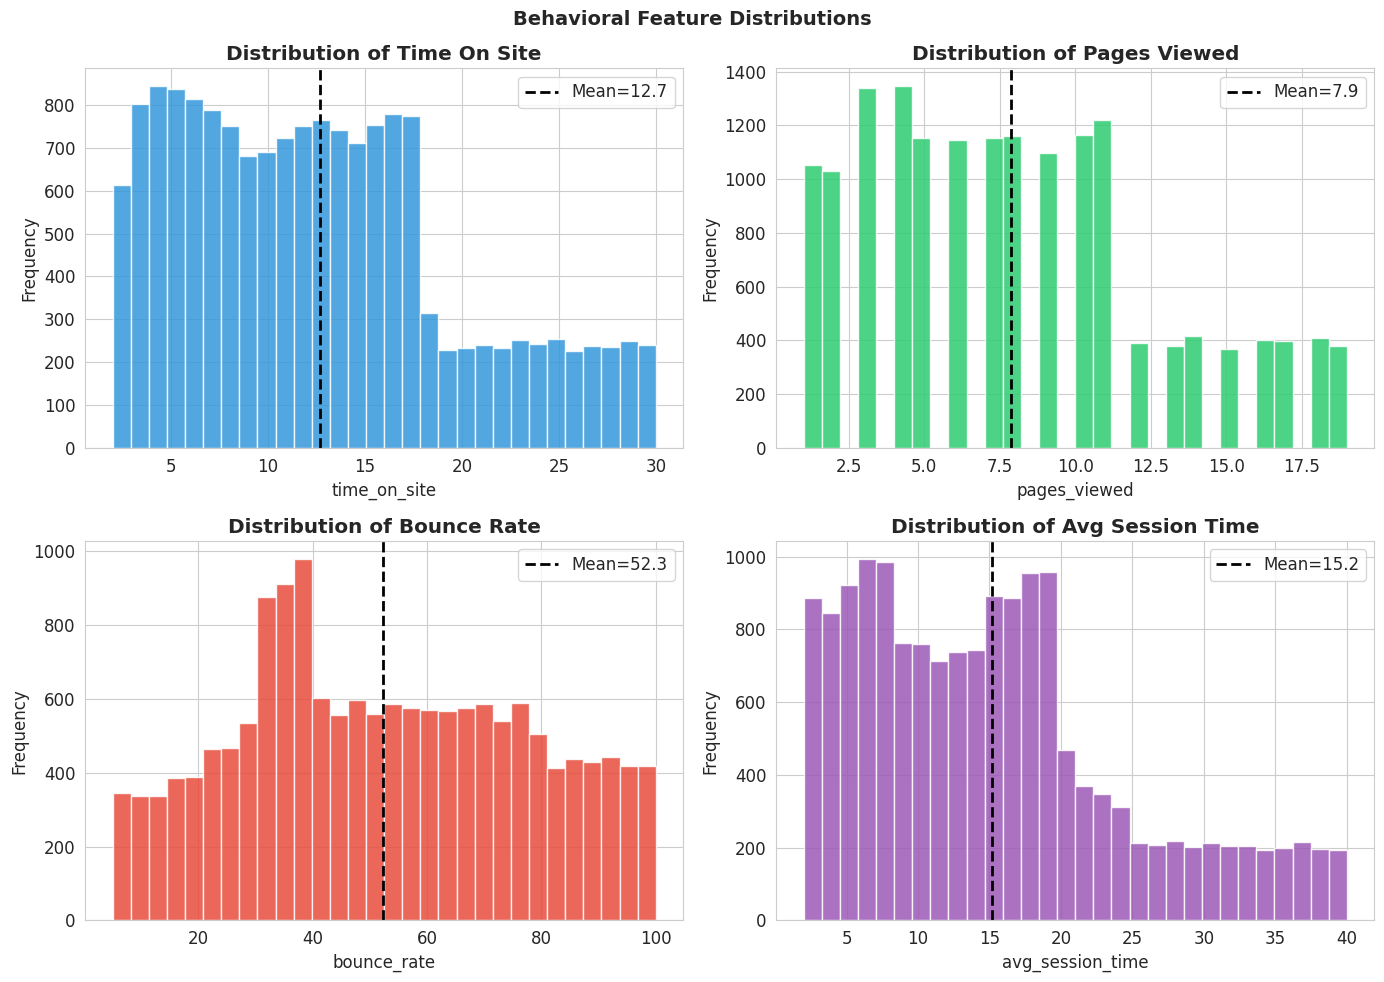


Key Insights:
=> Average time on site: 12.7 minutes
=> Average pages viewed: 7.9 pages
=> Bounce rate appears uniformly distributed (0–100%)


In [81]:
# ============================================================
#  CHART 3: BEHAVIORAL FEATURES DISTRIBUTION
# ============================================================

behavioral_features = ['time_on_site', 'pages_viewed', 'bounce_rate', 'avg_session_time']
colors_list = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(behavioral_features, colors_list)):
    axes[i].hist(df_clean[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(df_clean[col].mean(), color='black', linestyle='--', linewidth=2,
                    label=f'Mean={df_clean[col].mean():.1f}')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}',
                      fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Behavioral Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey Insights:')
print(f'=> Average time on site: {df_clean["time_on_site"].mean():.1f} minutes')
print(f'=> Average pages viewed: {df_clean["pages_viewed"].mean():.1f} pages')
print(f'=> Bounce rate appears uniformly distributed (0–100%)')

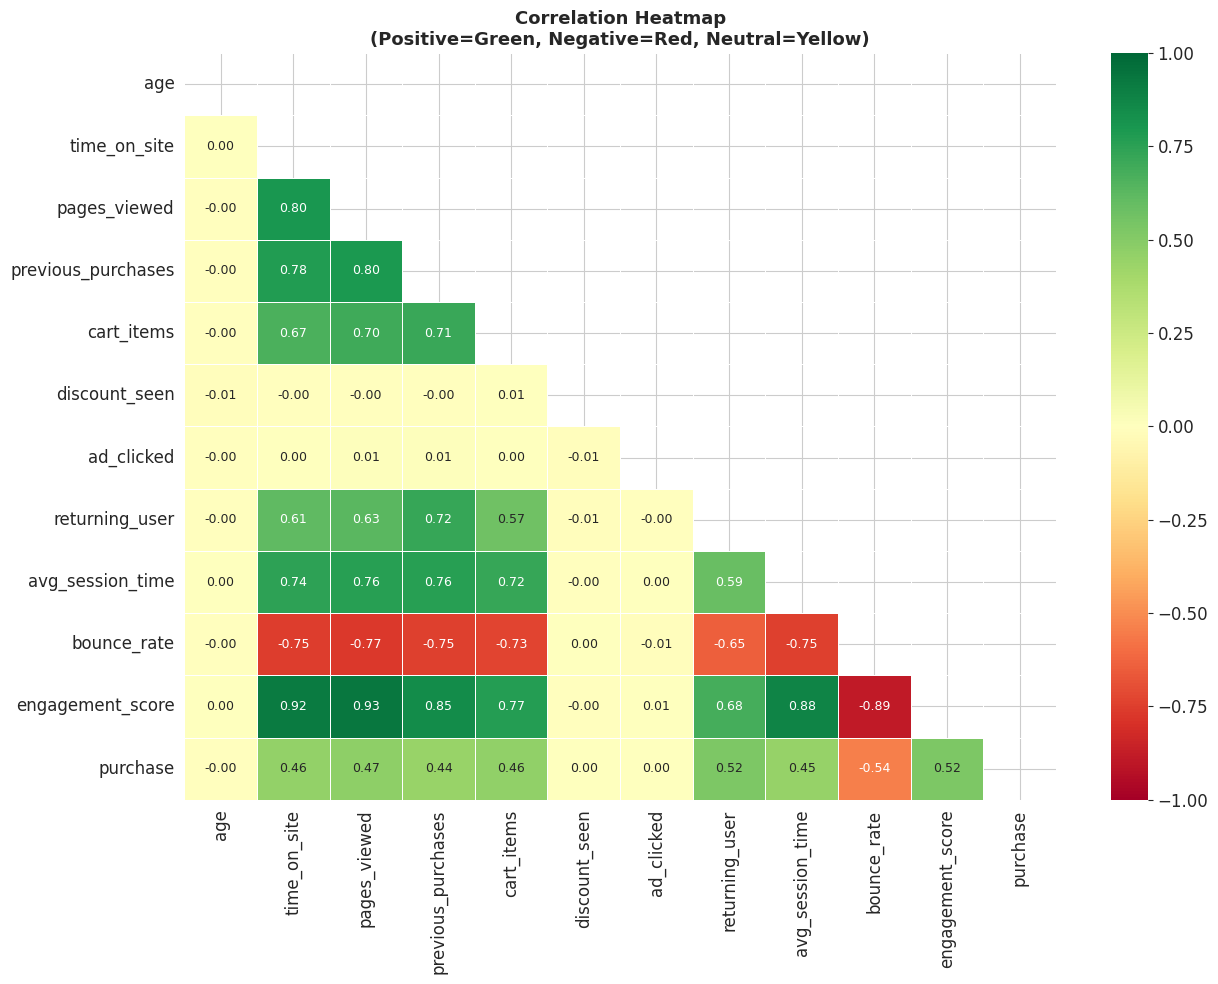


Features most correlated with PURCHASE:
   bounce_rate              : -0.540  ((-) negative)
   engagement_score         : +0.525  ((+) positive)
   returning_user           : +0.525  ((+) positive)
   pages_viewed             : +0.475  ((+) positive)
   cart_items               : +0.461  ((+) positive)
   time_on_site             : +0.457  ((+) positive)


In [83]:
# ============================================================
#  CHART 4: CORRELATION HEATMAP
#
#  Correlation measures how closely two variables move together.
#  - Correlation = +1 → Perfect positive relationship
#  - Correlation =  0 → No relationship
#  - Correlation = -1 → Perfect negative relationship
# ============================================================

corr_cols = ['age', 'time_on_site', 'pages_viewed', 'previous_purchases',
             'cart_items', 'discount_seen', 'ad_clicked', 'returning_user',
             'avg_session_time', 'bounce_rate', 'engagement_score', 'purchase']

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Only show lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap\n(Positive=Green, Negative=Red, Neutral=Yellow)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with 'purchase'
purchase_corr = corr_matrix['purchase'].drop('purchase').sort_values(key=abs, ascending=False)
print('\nFeatures most correlated with PURCHASE:')
for feat, corr_val in purchase_corr.head(6).items():
    direction = '(+) positive' if corr_val > 0 else '(-) negative'
    print(f'   {feat:<25}: {corr_val:+.3f}  ({direction})')

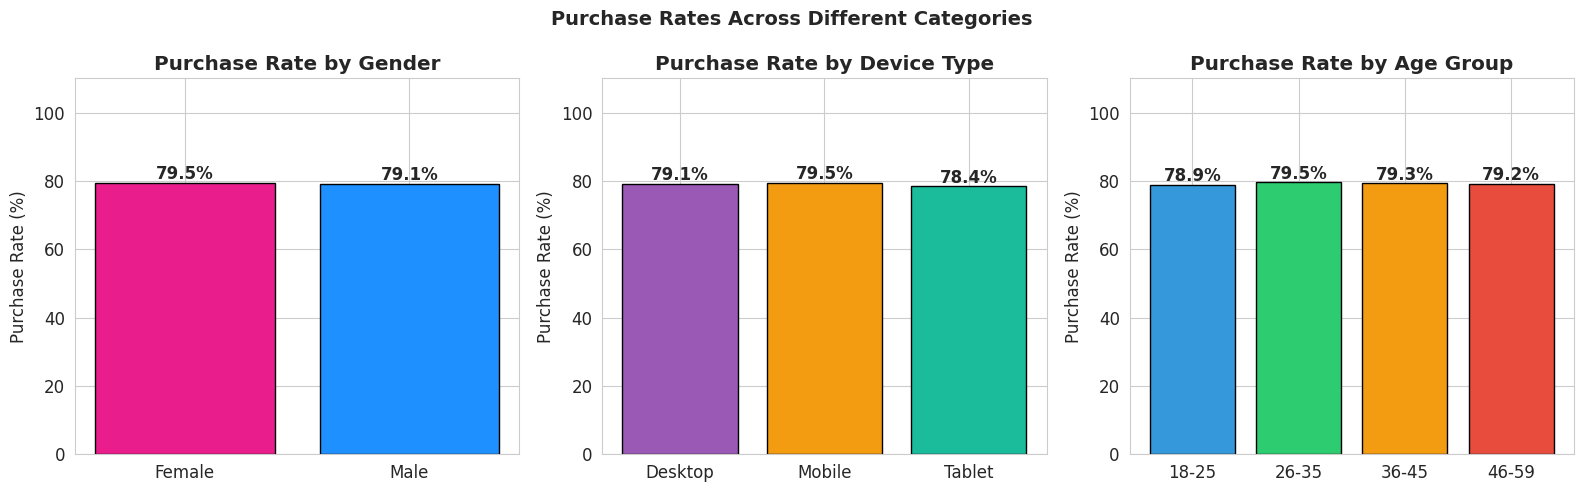

In [54]:
# ============================================================
#  CHART 5: PURCHASE RATE BY CATEGORY
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Purchase rate by gender
gender_purchase = df_clean.groupby('gender')['purchase'].mean().reset_index()
axes[0].bar(gender_purchase['gender'], gender_purchase['purchase'] * 100,
            color=['#E91E8C', '#1E90FF'], edgecolor='black')
axes[0].set_title('Purchase Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Purchase Rate (%)')
axes[0].set_ylim(0, 110)
for i, val in enumerate(gender_purchase['purchase']):
    axes[0].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontweight='bold')

# Purchase rate by device type
device_purchase = df_clean.groupby('device_type')['purchase'].mean().reset_index()
colors_dev = ['#9B59B6', '#F39C12', '#1ABC9C']
axes[1].bar(device_purchase['device_type'], device_purchase['purchase'] * 100,
            color=colors_dev, edgecolor='black')
axes[1].set_title('Purchase Rate by Device Type', fontweight='bold')
axes[1].set_ylabel('Purchase Rate (%)')
axes[1].set_ylim(0, 110)
for i, val in enumerate(device_purchase['purchase']):
    axes[1].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontweight='bold')

# Purchase rate by age group
age_purchase = df_clean.groupby('age_group', observed=False)['purchase'].mean().reset_index()
axes[2].bar(age_purchase['age_group'].astype(str), age_purchase['purchase'] * 100,
            color=['#3498DB', '#2ECC71', '#F39C12', '#E74C3C'], edgecolor='black')
axes[2].set_title('Purchase Rate by Age Group', fontweight='bold')
axes[2].set_ylabel('Purchase Rate (%)')
axes[2].set_ylim(0, 110)
for i, val in enumerate(age_purchase['purchase']):
    axes[2].text(i, val*100 + 1, f'{val*100:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Purchase Rates Across Different Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

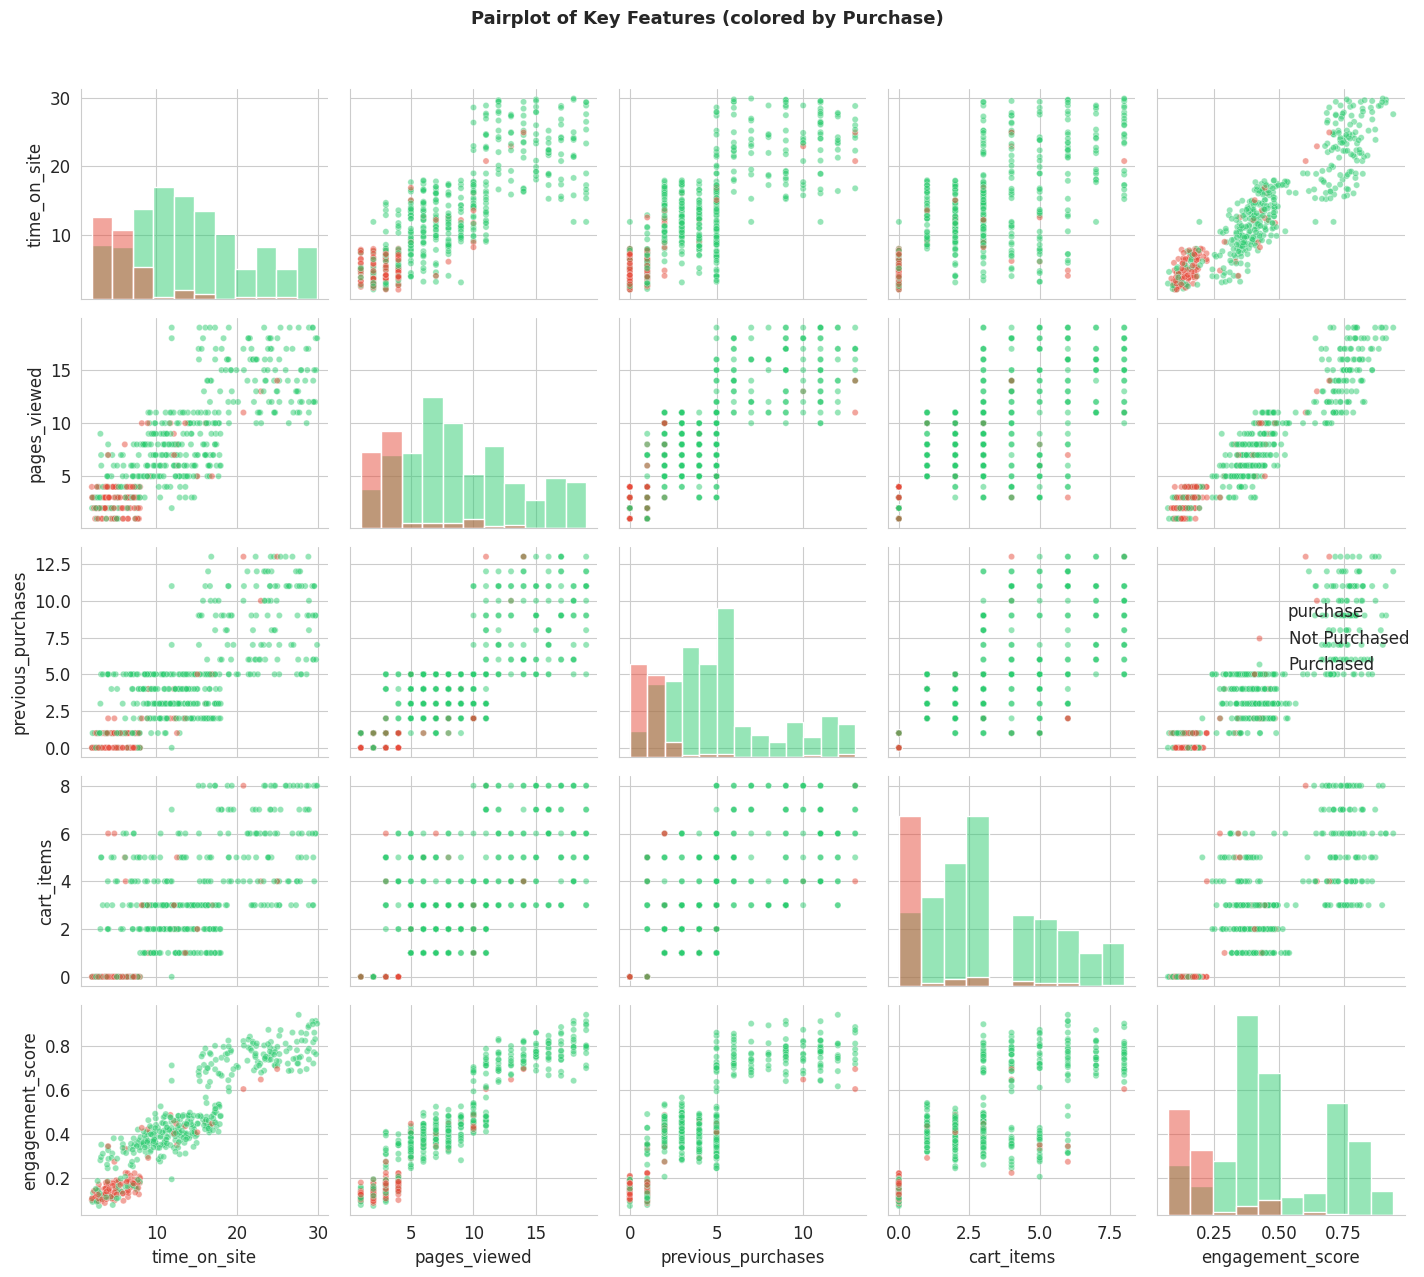

Tip: Look for clusters of one color — that indicates a feature combo
that predicts purchasing behavior.


In [55]:
# ============================================================
#  CHART 6: PAIRPLOT — RELATIONSHIPS BETWEEN KEY FEATURES
# ============================================================

pair_features = ['time_on_site', 'pages_viewed', 'previous_purchases',
                 'cart_items', 'engagement_score']

pair_df = df_clean[pair_features + ['purchase']].copy()
pair_df['purchase'] = pair_df['purchase'].map({1.0: 'Purchased', 0.0: 'Not Purchased'})

g = sns.pairplot(pair_df.sample(500, random_state=42),  # sample 500 for speed
                 hue='purchase',
                 palette={'Purchased': '#2ECC71', 'Not Purchased': '#E74C3C'},
                 diag_kind='hist', plot_kws={'alpha': 0.5, 's': 20})
g.fig.suptitle('Pairplot of Key Features (colored by Purchase)', y=1.02,
               fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

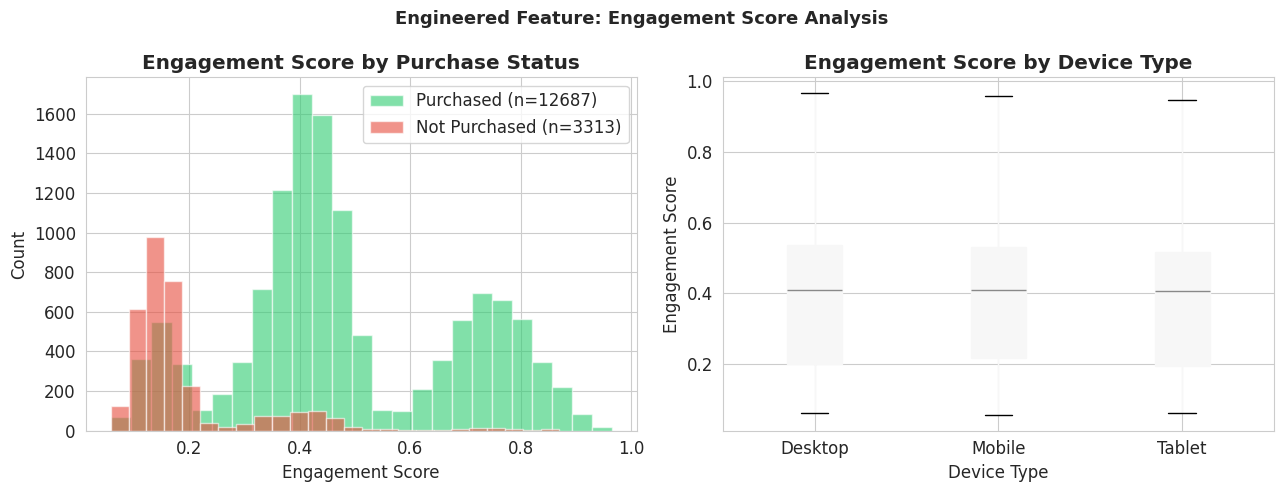

In [56]:
# ============================================================
#  CHART 7: ENGAGEMENT SCORE ANALYSIS
#  Our newly engineered feature — let's see how it behaves.
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Distribution by purchase
for purchase_val, label, color in [(1.0, 'Purchased', '#2ECC71'), (0.0, 'Not Purchased', '#E74C3C')]:
    subset = df_clean[df_clean['purchase'] == purchase_val]['engagement_score']
    ax1.hist(subset, bins=25, alpha=0.6, label=f'{label} (n={len(subset)})',
             color=color, edgecolor='white')
ax1.set_title('Engagement Score by Purchase Status', fontweight='bold')
ax1.set_xlabel('Engagement Score')
ax1.set_ylabel('Count')
ax1.legend()

# Engagement score by device type (box)
device_order = df_clean.groupby('device_type')['engagement_score'].median().sort_values().index
df_clean.boxplot(column='engagement_score', by='device_type', ax=ax2, patch_artist=True)
ax2.set_title('Engagement Score by Device Type', fontweight='bold')
ax2.set_xlabel('Device Type')
ax2.set_ylabel('Engagement Score')
fig.suptitle('')  # Remove auto suptitle from boxplot

plt.suptitle('Engineered Feature: Engagement Score Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Section 4: Clustering Analysis

We'll try three approaches:
- **K-Means**: Partitions data into K groups based on distance to centroid
- **Hierarchical Clustering**: Builds a tree of clusters (like a family tree)
- **DBSCAN**: Finds clusters based on density (great for irregular shapes)

   K=2: Inertia=62494, Silhouette=0.4817
   K=3: Inertia=40260, Silhouette=0.4223
   K=4: Inertia=34966, Silhouette=0.3397
   K=5: Inertia=32399, Silhouette=0.2862
   K=6: Inertia=30577, Silhouette=0.2795
   K=7: Inertia=27939, Silhouette=0.2360
   K=8: Inertia=26653, Silhouette=0.2081
   K=9: Inertia=25509, Silhouette=0.2030
   K=10: Inertia=24811, Silhouette=0.2007


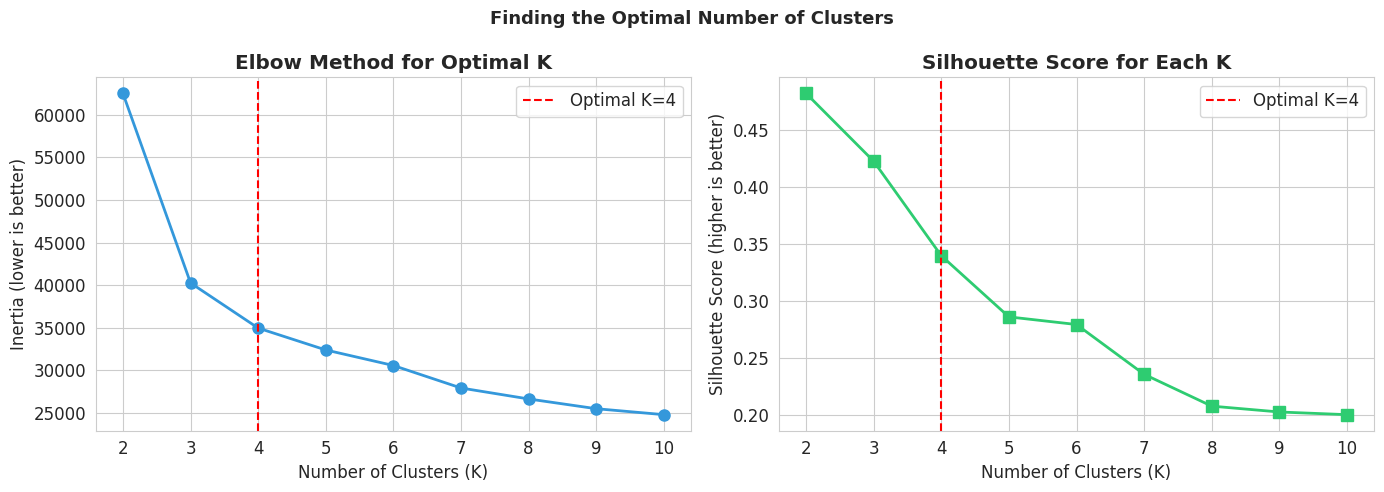


We choose K=4 based on the elbow point and silhouette score.


In [84]:
# ============================================================
#  K-MEANS CLUSTERING
#
#  → The ELBOW METHOD helps us find the optimal K!
# ============================================================

# Use a subset of scaled features for clustering
cluster_features = ['age', 'time_on_site', 'pages_viewed', 'previous_purchases',
                    'cart_items', 'avg_session_time', 'bounce_rate', 'engagement_score']

X_cluster = df_scaled[cluster_features].values

# --- ELBOW METHOD ---
# We run K-Means for K=1 to K=10 and record the 'inertia'
# (sum of squared distances from each point to its centroid).
# When the elbow appears (inertia stops dropping sharply), that's our K!
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_score = silhouette_score(X_cluster, km.labels_, sample_size=16000, random_state=42)
    silhouette_scores.append(sil_score)
    print(f'   K={k}: Inertia={km.inertia_:.0f}, Silhouette={sil_score:.4f}')

# Plot Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, 'o-', color='#3498DB', linewidth=2, markersize=8)
ax1.axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
ax1.set_title('Elbow Method for Optimal K', fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (lower is better)')
ax1.legend()

ax2.plot(list(K_range), silhouette_scores, 's-', color='#2ECC71', linewidth=2, markersize=8)
ax2.axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
ax2.set_title('Silhouette Score for Each K', fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score (higher is better)')
ax2.legend()

plt.suptitle('Finding the Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nWe choose K=4 based on the elbow point and silhouette score.')

In [85]:
# ============================================================
#  FIT FINAL K-MEANS MODEL WITH K=4
# ============================================================

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_cluster)

print(f'K-Means fit with K={optimal_k}')
print(f'   Final inertia: {kmeans.inertia_:.0f}')
print(f'   Silhouette Score: {silhouette_score(X_cluster, df_clean["kmeans_cluster"]):.4f}')
print()
print('Cluster sizes:')
print(df_clean['kmeans_cluster'].value_counts().sort_index())

# Profile each cluster
cluster_profile = df_clean.groupby('kmeans_cluster')[cluster_features].mean().round(2)
print('\nCluster Profiles (mean values):')
cluster_profile

K-Means fit with K=4
   Final inertia: 34966
   Silhouette Score: 0.3397

Cluster sizes:
kmeans_cluster
0    4048
1    4103
2    3875
3    3974
Name: count, dtype: int64

Cluster Profiles (mean values):


,age,time_on_site,pages_viewed,previous_purchases,cart_items,avg_session_time,bounce_rate,engagement_score
kmeans_cluster,,,,,,,,
0,45.29,11.88,7.41,3.36,2.59,14.34,49.96,0.41
1,37.71,5.05,2.49,0.52,0.02,5.02,84.83,0.15
2,37.69,22.46,14.55,8.96,5.47,27.71,22.61,0.75
3,29.60,11.81,7.42,3.35,2.59,14.35,49.99,0.41


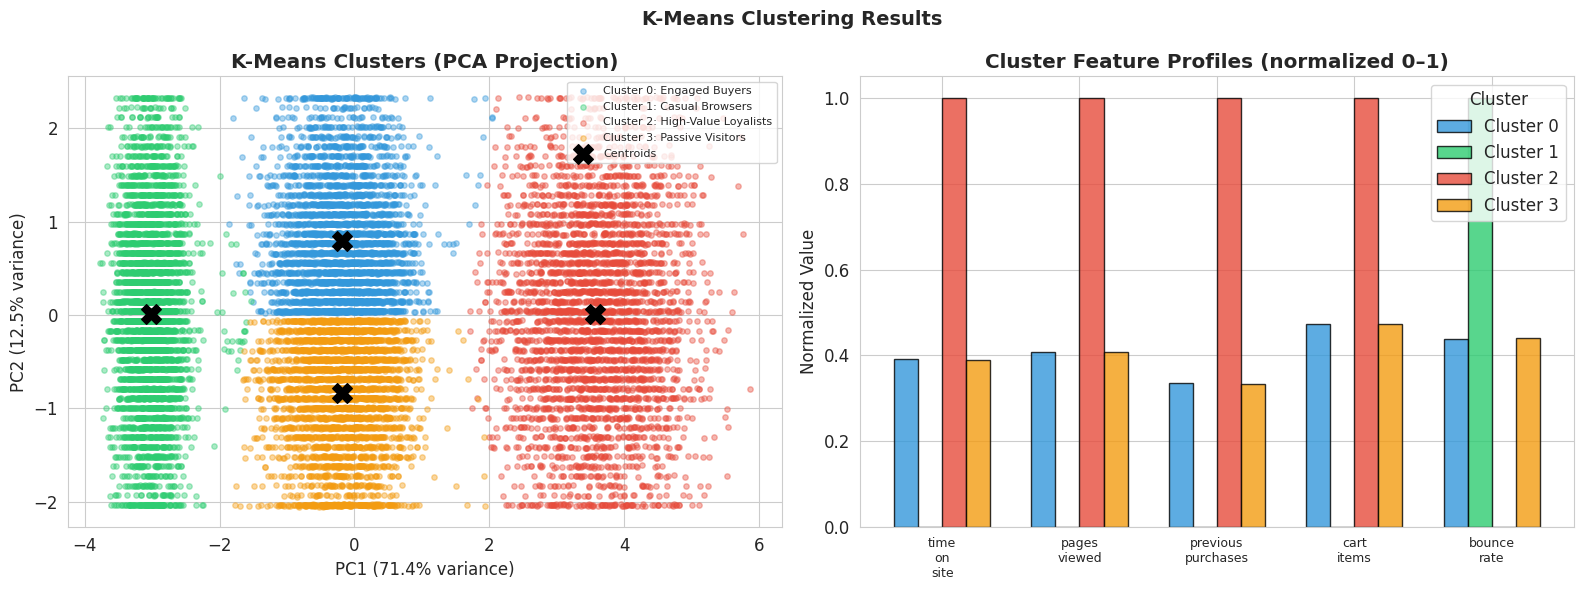


Cluster Interpretations:
   Cluster 0: Engaged Buyers: 4,048 users
   Cluster 1: Casual Browsers: 4,103 users
   Cluster 2: High-Value Loyalists: 3,875 users
   Cluster 3: Passive Visitors: 3,974 users


In [71]:
# ============================================================
#  VISUALIZE CLUSTERS
#  We use PCA (Principal Component Analysis) to compress our
#  8-dimensional data down to 2D so we can plot it.
#  PCA finds the 2 directions with the most variation in data.
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

# Name the clusters based on their profiles
cluster_names = {
    0: 'Cluster 0: Engaged Buyers',
    1: 'Cluster 1: Casual Browsers',
    2: 'Cluster 2: High-Value Loyalists',
    3: 'Cluster 3: Passive Visitors'
}

colors_clusters = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
for i in range(optimal_k):
    mask = df_clean['kmeans_cluster'] == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_clusters[i], label=cluster_names[i],
                alpha=0.4, s=15)

# Plot centroids
centers_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', s=200, marker='X', zorder=5, label='Centroids')
ax1.set_title('K-Means Clusters (PCA Projection)', fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax1.legend(fontsize=8, loc='upper right')

# Radar chart / bar profile
profile_plot = df_clean.groupby('kmeans_cluster')[['time_on_site','pages_viewed',
    'previous_purchases','cart_items','bounce_rate']].mean()
profile_norm = (profile_plot - profile_plot.min()) / (profile_plot.max() - profile_plot.min())
profile_norm.T.plot(kind='bar', ax=ax2, color=colors_clusters[:optimal_k],
                    width=0.7, edgecolor='black', alpha=0.8)
ax2.set_title('Cluster Feature Profiles (normalized 0–1)', fontweight='bold')
ax2.set_ylabel('Normalized Value')
ax2.set_xticklabels([c.replace('_', '\n') for c in profile_plot.columns], rotation=0, fontsize=9)
ax2.legend([f'Cluster {i}' for i in range(optimal_k)], title='Cluster')

plt.suptitle('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCluster Interpretations:')
for i, name in cluster_names.items():
    size = (df_clean['kmeans_cluster'] == i).sum()
    print(f'   {name}: {size:,} users')

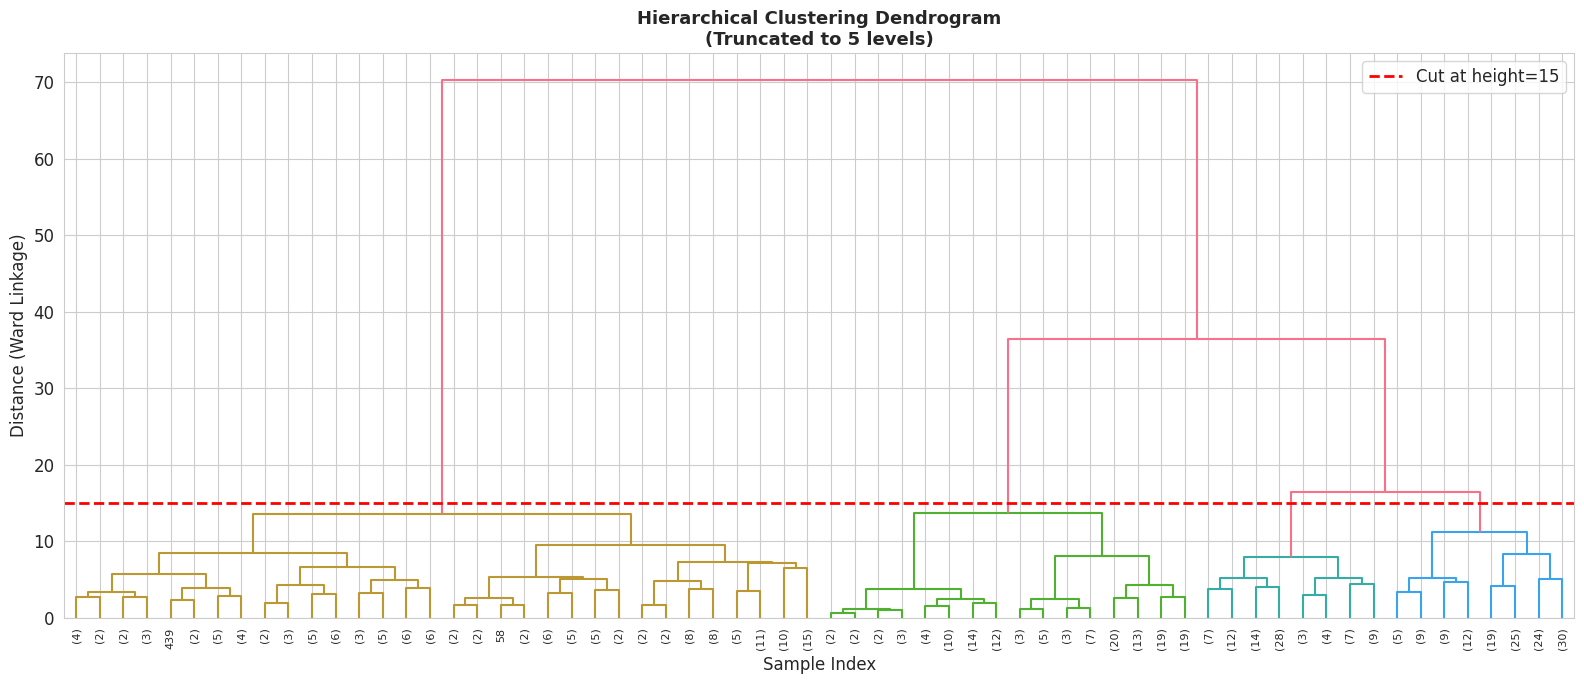

Agglomerative Clustering fitted with 4 clusters
Cluster distribution: {np.int64(0): np.int64(4075), np.int64(1): np.int64(3895), np.int64(2): np.int64(6356), np.int64(3): np.int64(1674)}
Silhouette Score: 0.3038


In [86]:
# ============================================================
#  HIERARCHICAL CLUSTERING + DENDROGRAM
# ============================================================

# Use a sample of 500 points (dendrogram gets slow with thousands)
sample_idx = np.random.choice(len(X_cluster), size=500, replace=False)
X_hier_sample = X_cluster[sample_idx]

# Compute linkage matrix (using Ward method — minimizes variance within clusters)
Z = linkage(X_hier_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z, ax=ax,
           truncate_mode='level', p=5,  # Show only last 5 merge levels
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=15)
ax.axhline(y=15, color='red', linestyle='--', linewidth=2, label='Cut at height=15')
ax.set_title('Hierarchical Clustering Dendrogram\n(Truncated to 5 levels)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Distance (Ward Linkage)')
ax.legend()
plt.tight_layout()
plt.show()

# Fit on full dataset
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df_clean['hier_cluster'] = agg.fit_predict(X_cluster)
print('Agglomerative Clustering fitted with 4 clusters')
print('Cluster distribution:', dict(zip(*np.unique(df_clean['hier_cluster'], return_counts=True))))

hier_sil = silhouette_score(X_cluster, df_clean['hier_cluster'], sample_size=16000, random_state=42)
print(f'Silhouette Score: {hier_sil:.4f}')

DBSCAN Results:
   Clusters found: 3
   Noise points:   91 (0.6%)


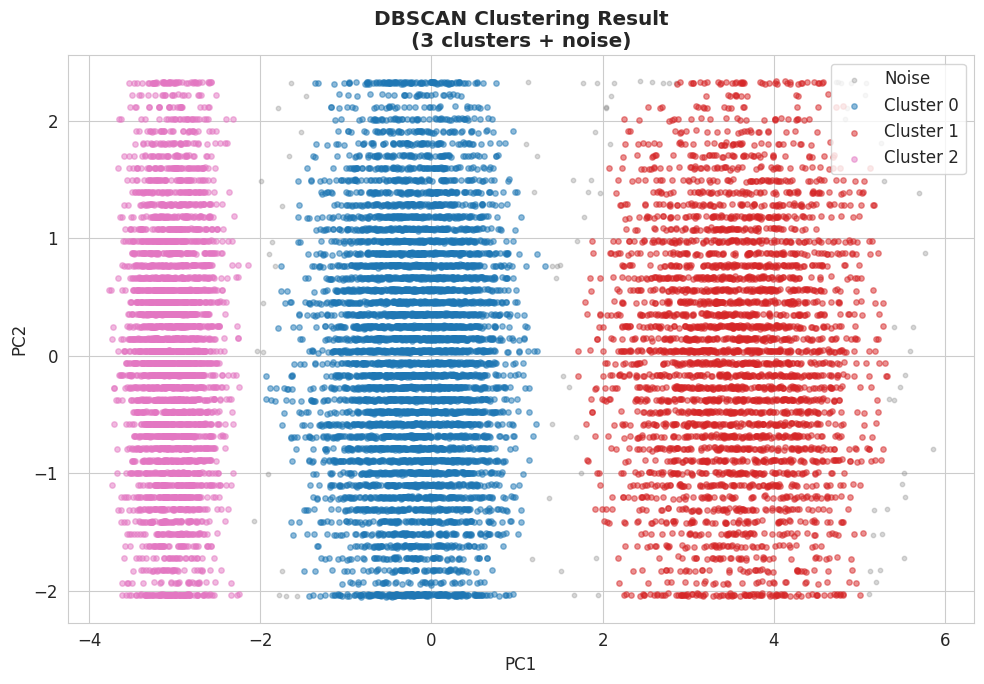

In [93]:
# ============================================================
#  DBSCAN CLUSTERING
#  DBSCAN = Density-Based Spatial Clustering of Applications
#          with Noise
#  Parameters:
#  - eps: maximum distance between two points to be neighbors
#  - min_samples: minimum points needed to form a dense region
# ============================================================

# Use only 2D PCA projection for DBSCAN (easier to tune eps)
dbscan = DBSCAN(eps=0.3, min_samples=20)
dbscan_labels = dbscan.fit_predict(X_pca)  # Use PCA-reduced data

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = list(dbscan_labels).count(-1)

print(f'DBSCAN Results:')
print(f'   Clusters found: {n_clusters_db}')
print(f'   Noise points:   {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)')

# Visualize DBSCAN
fig, ax = plt.subplots(figsize=(10, 7))
unique_labels = sorted(set(dbscan_labels))
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

for label in unique_labels:
    mask = dbscan_labels == label
    if label == -1:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c='gray', alpha=0.3, s=10, label='Noise')
    else:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=cmap(label), alpha=0.5, s=15, label=f'Cluster {label}')

ax.set_title(f'DBSCAN Clustering Result\n({n_clusters_db} clusters + noise)',
             fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
# Section 5: Classification & Prediction Models

We'll train three models:
1. **Decision Tree** — Like a flowchart of yes/no questions
2. **Support Vector Machine (SVM)** — Finds the best boundary between classes

In [62]:
# ============================================================
#  PREPARE DATA FOR CLASSIFICATION
#
#  X = features (inputs)
#  y = target (what we want to predict)
#
#  train_test_split: splits data so we train on 80% and test
#  on the remaining 20% (data the model has never seen).
#  This gives us a fair measure of real-world performance.
# ============================================================

# Feature columns (exclude ID, target, and cluster labels we added)
feature_cols = ['age', 'time_on_site', 'pages_viewed', 'previous_purchases',
                'cart_items', 'discount_seen', 'ad_clicked', 'returning_user',
                'avg_session_time', 'bounce_rate', 'engagement_score',
                'high_value_user', 'interaction_score', 'gender_encoded',
                'device_Desktop', 'device_Mobile', 'device_Tablet']

# Make sure device columns exist
available_features = [f for f in feature_cols if f in df_encoded.columns]

X = df_encoded[available_features].values
y = df_encoded['purchase'].values

# Scale for distance-based models
scaler_cls = StandardScaler()
X_scaled_cls = scaler_cls.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled_cls, y, test_size=0.2, random_state=42, stratify=y)

print('Train/Test Split:')
print(f'   Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'   Features used:  {X_train.shape[1]}')
print(f'   Class balance in training: {np.bincount(y_train.astype(int))}')

Train/Test Split:
   Training set:   12,800 samples (80%)
   Test set:       3,200 samples (20%)
   Features used:  17
   Class balance in training: [ 2650 10150]


Decision Tree Results:
   Training Accuracy: 87.28%
   Test Accuracy:     87.03%
   Precision:         0.9601
   Recall:            0.8727
   F1-Score:          0.9143
   ROC-AUC:           0.8925


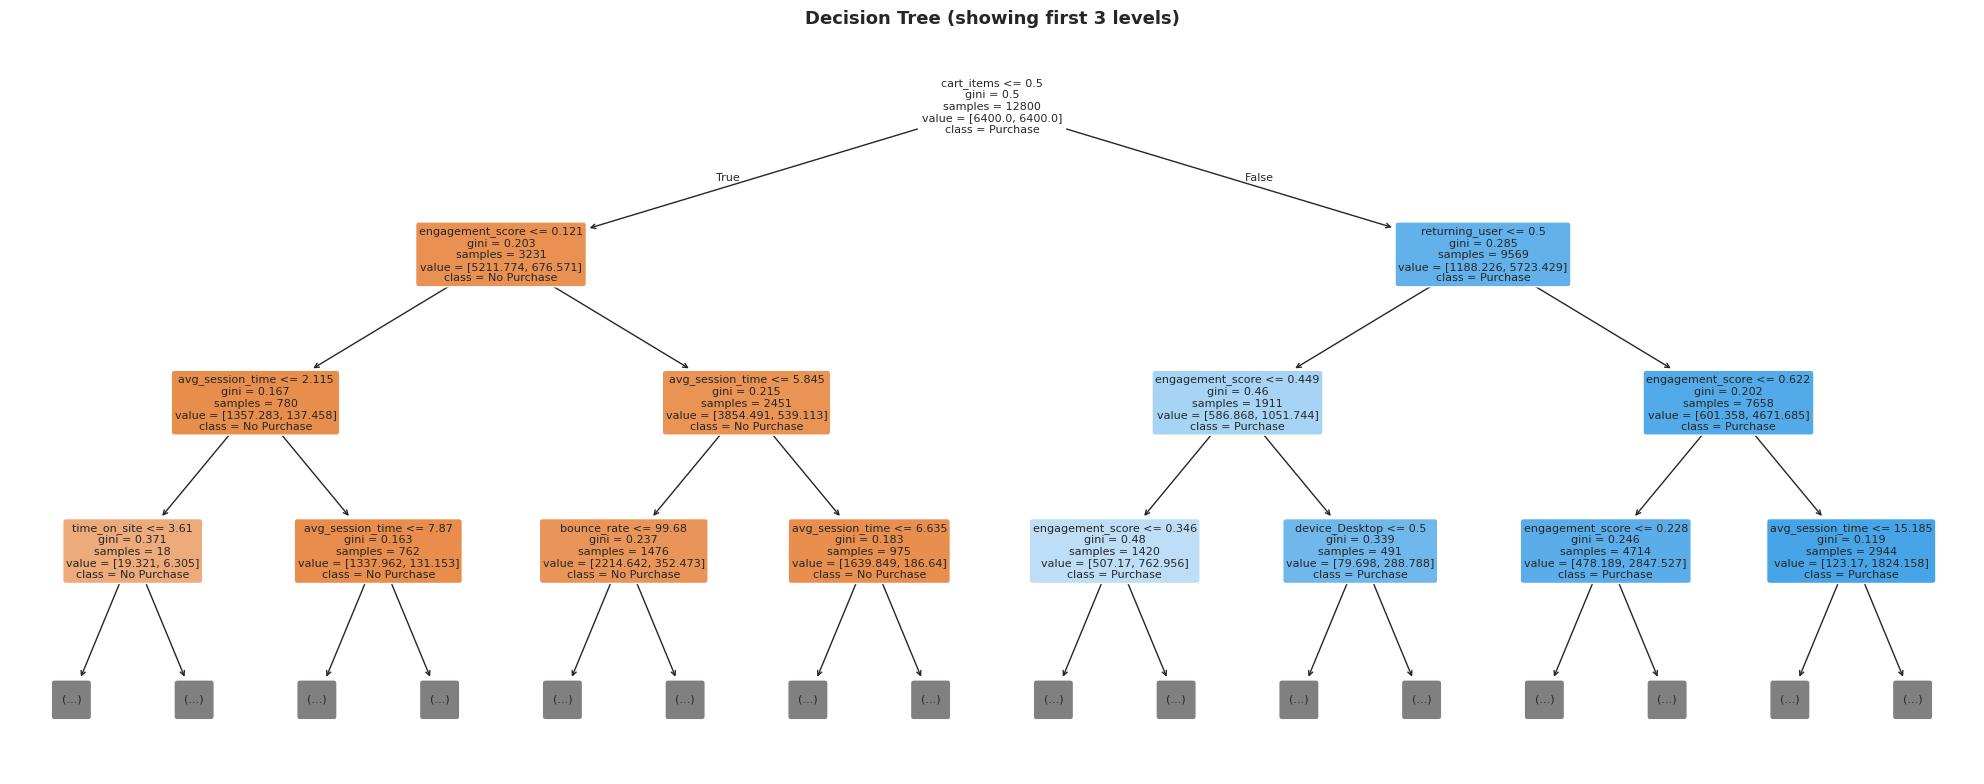

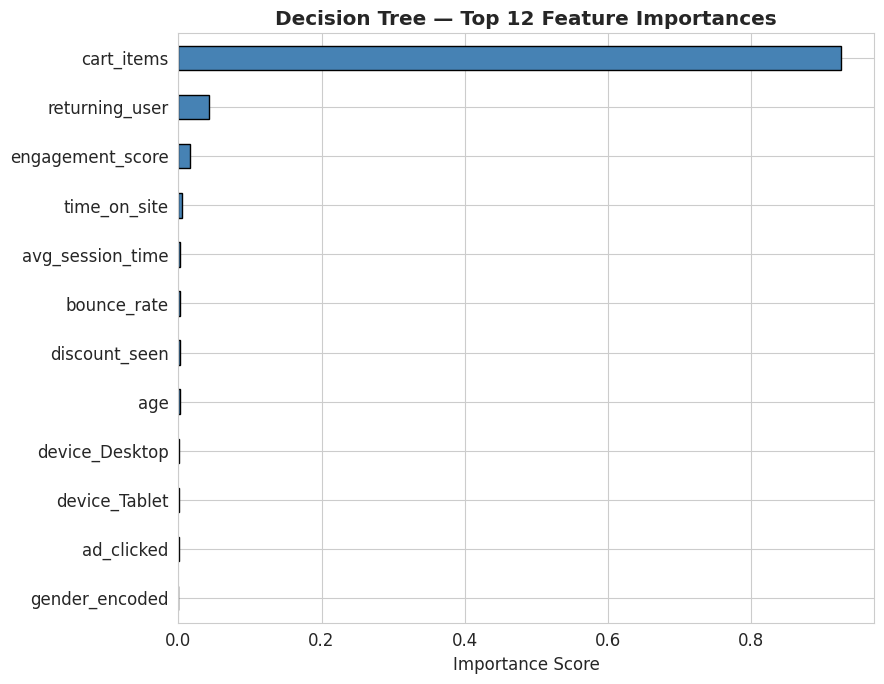

In [63]:
# ============================================================
#  MODEL 1: DECISION TREE
#  Pros: Easy to understand, no scaling needed
#  Cons: Can overfit (memorize training data, fail on new data)
#  Solution: Limit max_depth to prevent overfitting
# ============================================================

dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('Decision Tree Results:')
print(f'   Training Accuracy: {dt.score(X_train, y_train)*100:.2f}%')
print(f'   Test Accuracy:     {accuracy_score(y_test, y_pred_dt)*100:.2f}%')
print(f'   Precision:         {precision_score(y_test, y_pred_dt):.4f}')
print(f'   Recall:            {recall_score(y_test, y_pred_dt):.4f}')
print(f'   F1-Score:          {f1_score(y_test, y_pred_dt):.4f}')
print(f'   ROC-AUC:           {roc_auc_score(y_test, y_prob_dt):.4f}')

# Visualize the decision tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=available_features,
          class_names=['No Purchase', 'Purchase'],
          filled=True, rounded=True, ax=ax, fontsize=8)
ax.set_title('Decision Tree (showing first 3 levels)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Importance
fi = pd.Series(dt.feature_importances_, index=available_features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
fi.tail(12).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Decision Tree — Top 12 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [95]:
# ============================================================
#  MODEL 2: SUPPORT VECTOR MACHINE (SVM)
#
#  SVM finds the OPTIMAL HYPERPLANE (decision boundary) that
#  maximizes the margin between classes.
#
#  The 'support vectors' are the data points closest to the
#  boundary — they define where the boundary goes.
#
#  We use kernel='rbf' (Radial Basis Function) which can handle
#  non-linear boundaries.
#
#  SVM requires SCALED data! We use X_train_s here.
# ============================================================

# Use a sample for speed (SVM is slow on large datasets)
# svm_sample = min(16000, len(X_train_s))
# idx_svm = np.random.choice(len(X_train_s), size=svm_sample, replace=False)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
          class_weight='balanced', random_state=42)
svm.fit(X_train_s, y_train)

y_pred_svm = svm.predict(X_test_s)
y_prob_svm = svm.predict_proba(X_test_s)[:, 1]

print('SVM (RBF Kernel) Results:')
print(f'   Training Accuracy: {svm.score(X_train_s, y_train)*100:.2f}%')
print(f'   Test Accuracy:     {accuracy_score(y_test, y_pred_svm)*100:.2f}%')
print(f'   Precision:         {precision_score(y_test, y_pred_svm):.4f}')
print(f'   Recall:            {recall_score(y_test, y_pred_svm):.4f}')
print(f'   F1-Score:          {f1_score(y_test, y_pred_svm):.4f}')
print(f'   ROC-AUC:           {roc_auc_score(y_test, y_prob_svm):.4f}')
# print(f'   (Trained on {svm_sample} samples for speed)')

SVM (RBF Kernel) Results:
   Training Accuracy: 87.52%
   Test Accuracy:     87.62%
   Precision:         0.9592
   Recall:            0.8814
   F1-Score:          0.9187
   ROC-AUC:           0.8918


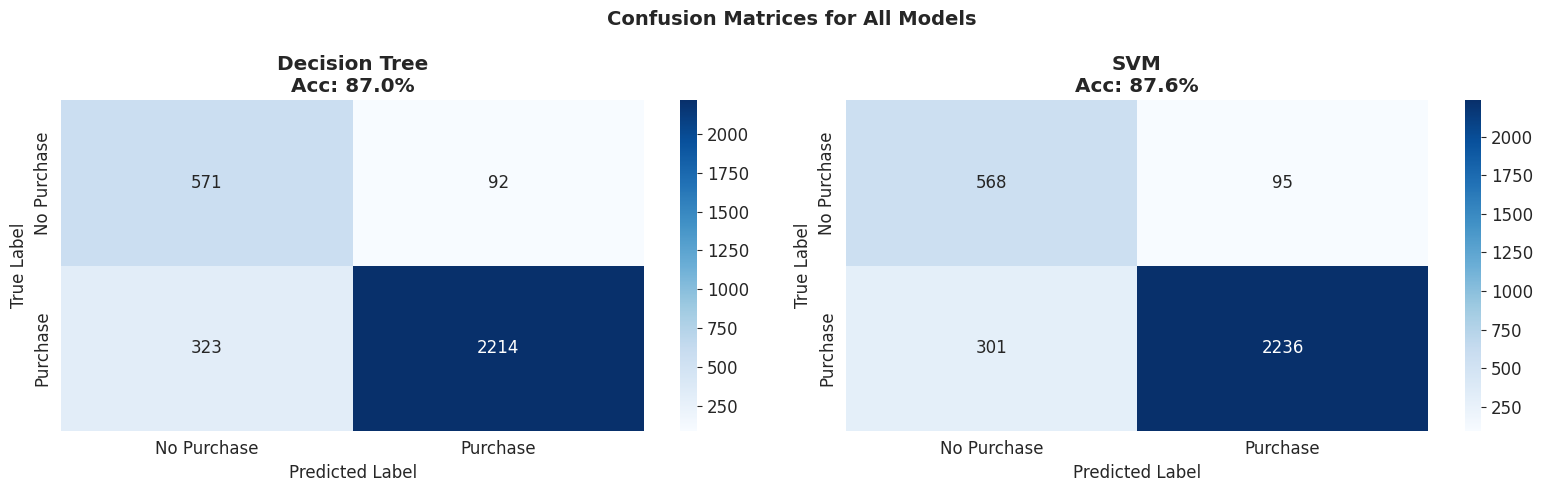

In [96]:
# ============================================================
#  CONFUSION MATRICES
#
#  A confusion matrix shows us EXACTLY what the model predicted:
#
#                  Predicted NO    Predicted YES
#  Actual NO    [  True Negative  |  False Positive  ]
#  Actual YES   [  False Negative |  True Positive   ]
#
#  True Positive  (TP): Correctly predicted purchase
#  True Negative  (TN): Correctly predicted no purchase
#  False Positive (FP): Said "will buy" but didn't (Type I error)
#  False Negative (FN): Said "won't buy" but did (Type II error)
# ============================================================

models_preds = [
    ('Decision Tree', y_pred_dt),
    ('SVM', y_pred_svm),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred)*100:.1f}%',
                 fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [66]:
# ============================================================
#  LOGISTIC REGRESSION (Classification with probabilities)
#
#  If probability > 0.5 → predict Purchase
#  If probability ≤ 0.5 → predict No Purchase
# ============================================================

log_reg = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
log_reg.fit(X_train_s, y_train)

y_pred_lr  = log_reg.predict(X_test_s)
y_prob_lr  = log_reg.predict_proba(X_test_s)[:, 1]

print('Logistic Regression — Purchase Prediction:')
print('='*50)
print(f'   Accuracy:  {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'   Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'   Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'   F1-Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'   ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')

Logistic Regression — Purchase Prediction:
   Accuracy:  85.19%
   Precision: 0.9615
   Recall:    0.8471
   F1-Score:  0.9007
   ROC-AUC:   0.8993


---
# Section 6: Model Evaluation & Overfitting Analysis


In [98]:
# ============================================================
#  5-FOLD CROSS-VALIDATION
#
#  The data is split into 5 equal parts (folds).
#  We train on 4 folds and test on 1 fold, repeated 5 times.
#  Each fold gets to be the test set exactly once.
#  Final score = average across all 5 test folds.
#
#  StratifiedKFold preserves the class ratio in each fold.
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Decision Tree (depth=5)' : DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Decision Tree (depth=20)': DecisionTreeClassifier(max_depth=20, random_state=42),
    'Decision Tree (no limit)': DecisionTreeClassifier(random_state=42),
    'Logistic Regression'     : LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
}

cv_results = {}
print('5-Fold Cross-Validation Results:')
print('='*70)
print(f'   {"Model":<35} {"Mean F1":>8} {"Std F1":>8} {"Mean Acc":>10}')
print('-'*70)

for name, model in models_cv.items():
    f1_scores  = cross_val_score(model, X_scaled_cls, y, cv=cv, scoring='f1')
    acc_scores = cross_val_score(model, X_scaled_cls, y, cv=cv, scoring='accuracy')
    cv_results[name] = {'f1': f1_scores, 'acc': acc_scores}
    print(f'   {name:<35} {f1_scores.mean():>8.4f} {f1_scores.std():>8.4f} {acc_scores.mean():>10.4f}')

print()
print('Notice: Decision Tree (no limit) may have high accuracy but often')
print('   overfits — it memorizes training data but generalizes poorly.')

5-Fold Cross-Validation Results:
   Model                                Mean F1   Std F1   Mean Acc
----------------------------------------------------------------------
   Decision Tree (depth=5)               0.9174   0.0018     0.8735
   Decision Tree (depth=20)              0.8844   0.0023     0.8174
   Decision Tree (no limit)              0.8810   0.0016     0.8110
   Logistic Regression                   0.9040   0.0039     0.8555

Notice: Decision Tree (no limit) may have high accuracy but often
   overfits — it memorizes training data but generalizes poorly.


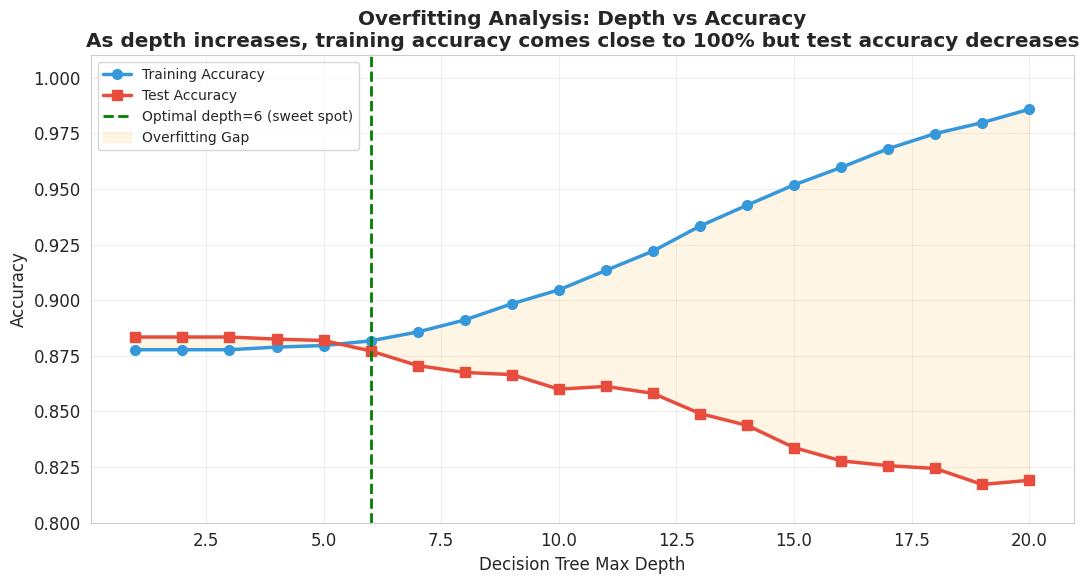


Key Takeaway:
   At depth=1:  Train=0.8777, Test=0.8834 ← UNDERFITTING
   At depth=6:  Train=0.8817, Test=0.8772 ← GOOD FIT
   At depth=20: Train=0.9858, Test=0.8191 ← OVERFITTING


In [99]:
# ============================================================
#  OVERFITTING DETECTION: TRAIN vs TEST PERFORMANCE
#
#  A large gap between training and test performance = overfitting.
#  We test Decision Trees at different depths to visualize this.
# ============================================================

depths = range(1, 21)
train_scores, test_scores = [], []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt_temp.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt_temp.predict(X_test)))

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(depths, train_scores, 'o-', color='#3498DB', linewidth=2.5,
        markersize=7, label='Training Accuracy')
ax.plot(depths, test_scores, 's-', color='#E74C3C', linewidth=2.5,
        markersize=7, label='Test Accuracy')
ax.axvline(x=6, color='green', linestyle='--', linewidth=2,
           label='Optimal depth=6 (sweet spot)')

# Annotate the gap
ax.fill_between(depths, train_scores, test_scores, alpha=0.1, color='orange',
                label='Overfitting Gap')

ax.set_xlabel('Decision Tree Max Depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overfitting Analysis: Depth vs Accuracy\n'
             'As depth increases, training accuracy comes close to 100% but test accuracy decreases',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.8, 1.01)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nKey Takeaway:')
print(f'   At depth=1:  Train={train_scores[0]:.4f}, Test={test_scores[0]:.4f} ← UNDERFITTING')
print(f'   At depth=6:  Train={train_scores[5]:.4f}, Test={test_scores[5]:.4f} ← GOOD FIT')
print(f'   At depth=20: Train={train_scores[19]:.4f}, Test={test_scores[19]:.4f} ← OVERFITTING')

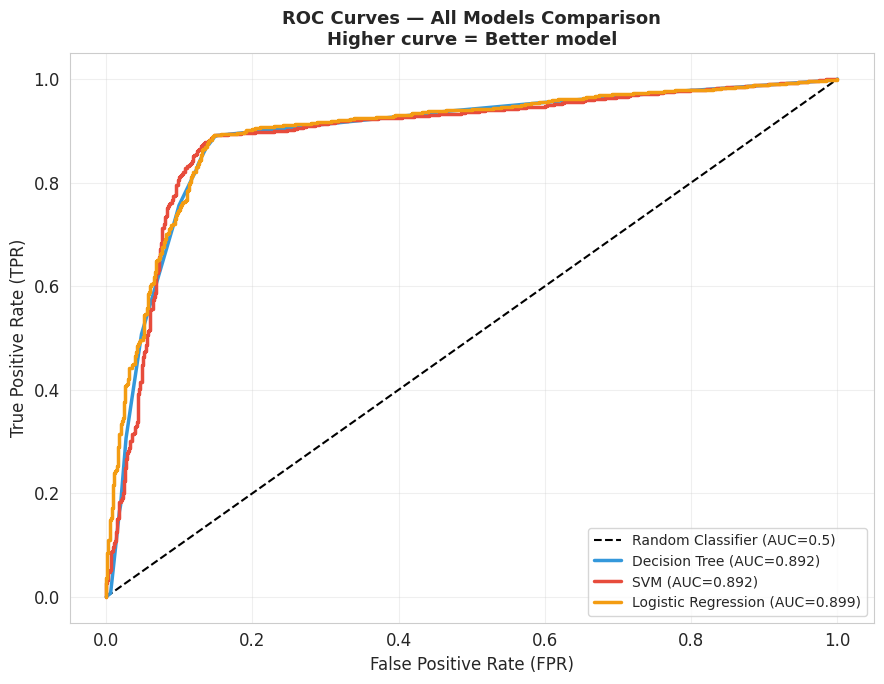

In [100]:
# ============================================================
#  ROC CURVES
#
#  ROC = Receiver Operating Characteristic
#  AUC = Area Under the Curve
#
#  The ROC curve plots:
#  - X-axis: False Positive Rate (FPR) = FP / (FP + TN)
#  - Y-axis: True Positive Rate (TPR) = TP / (TP + FN)
#
#  AUC = 1.0 → Perfect model
#  AUC = 0.5 → Random guessing (diagonal line)
#  AUC > 0.7 → Acceptable | > 0.8 → Good | > 0.9 → Excellent
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC=0.5)')

# Plot each model
roc_models = [
    ('Decision Tree', y_prob_dt, '#3498DB'),
    ('SVM', y_prob_svm, '#E74C3C'),
    ('Logistic Regression', y_prob_lr, '#F39C12'),
]

for name, y_prob, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title('ROC Curves — All Models Comparison\n'
             'Higher curve = Better model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
# ============================================================
#  COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================

comparison_data = {
    'Model': ['Decision Tree', 'SVM (RBF)', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_lr)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_lr)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_lr)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_lr)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Model')
comparison_df = comparison_df.round(4)

print('COMPREHENSIVE MODEL COMPARISON:')
print('='*70)
print(comparison_df.to_string())

# Highlight best values
print('\nBest Performers:')
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_val = comparison_df[metric].max()
    print(f'   {metric:<15}: {best_model:<22} ({best_val:.4f})')

COMPREHENSIVE MODEL COMPARISON:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Decision Tree          0.8703     0.9601  0.8727    0.9143   0.8925
SVM (RBF)              0.8775     0.9597  0.8825    0.9195   0.8925
Logistic Regression    0.8519     0.9615  0.8471    0.9007   0.8993

Best Performers:
   Accuracy       : SVM (RBF)              (0.8775)
   Precision      : Logistic Regression    (0.9615)
   Recall         : SVM (RBF)              (0.8825)
   F1-Score       : SVM (RBF)              (0.9195)
   ROC-AUC        : Logistic Regression    (0.8993)
